In [2]:
from lib.readwav import readwav
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [3]:
%matplotlib widget
plt.close('all')

In [4]:
note_data = readwav('Data_organ/note_1.wav')
rate, data = note_data
print(data.shape)
chanel1 = data[:,0]
chanel2 = data[:,1]

(332193, 2)


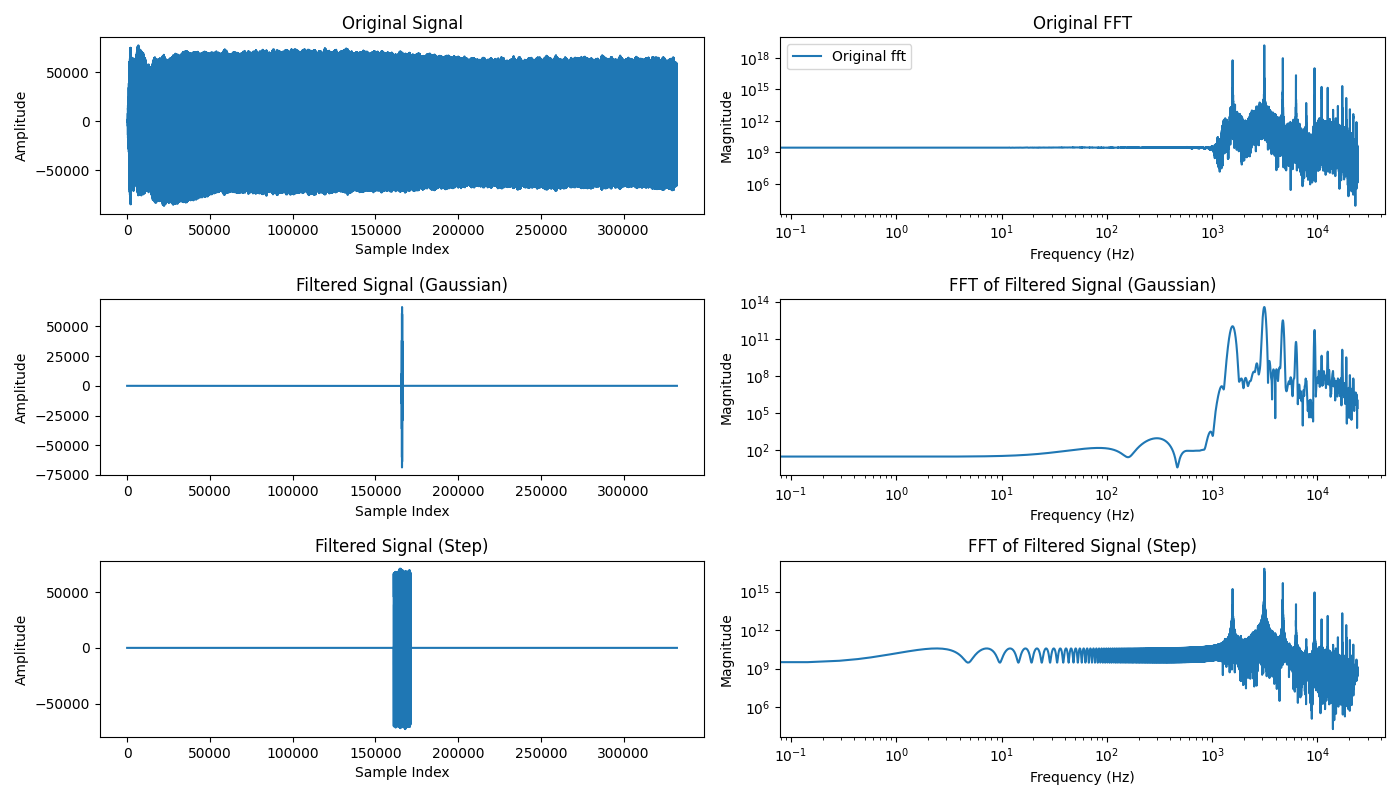

In [5]:
data = chanel1

N = len(data)
n = np.arange(N)

window_size_gauss_fine = 200#round(N*0.03)
window_size_gauss_coarse = round(N*0.6)
window_size_step = round(N*0.03)

gaussian_window_fine = np.exp(-0.5 * ((n - N/2) / (window_size_gauss_fine/2))**2)
step_window = np.zeros(N)
step_window[N // 2 - window_size_step // 2:N // 2 + window_size_step//2] = 1

filtered_data_gauss = gaussian_window_fine * data
filtered_data_step = step_window * data

fft_data = sp.fft.rfft(data)
frequencies = sp.fft.rfftfreq(N, d=1/rate)

fft_filtered_data_gauss = sp.fft.rfft(filtered_data_gauss)
frequencies_filtered_gauss = sp.fft.rfftfreq(N, d=1/rate)

fft_filtered_data_step = sp.fft.rfft(filtered_data_step)
frequencies_filtered_step = sp.fft.rfftfreq(N, d=1/rate)

plt.figure(figsize=(14, 8))

plt.subplot(3,2,1)

plt.plot(n, data, label='Original Signal')
plt.title('Original Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')

plt.subplot(3,2,2)

plt.plot(frequencies, np.abs(fft_data)**2, label='Original fft')
plt.xscale('log')
plt.yscale('log')
plt.title('Original FFT')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.legend()

plt.subplot(3,2,3)
plt.plot(n, filtered_data_gauss, label='Filtered Signal (Gaussian)')
plt.title('Filtered Signal (Gaussian)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')

plt.subplot(3,2,4)
plt.plot(frequencies_filtered_gauss, np.abs(fft_filtered_data_gauss)**2, label='FFT of Filtered Signal (Gaussian)')
plt.xscale('log')
plt.yscale('log')
plt.title('FFT of Filtered Signal (Gaussian)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')

plt.subplot(3,2,5)
plt.plot(n, filtered_data_step, label='Filtered Signal (Step)')
plt.title('Filtered Signal (Step)')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')

plt.subplot(3,2,6)
plt.plot(frequencies_filtered_step, np.abs(fft_filtered_data_step)**2, label='FFT of Filtered Signal (Step)')
plt.xscale('log')
plt.yscale('log')
plt.title('FFT of Filtered Signal (Step)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')


plt.tight_layout()
plt.show()


In [27]:
plt.figure(figsize=(14, 8))

plt.subplot(2,1,1)

peaks, _ = sp.signal.find_peaks(np.abs(fft_filtered_data_gauss)**2, prominence=1e9)
prominences = sp.signal.peak_prominences(np.abs(fft_filtered_data_gauss)**2, peaks)[0]

all_peaks, _ = sp.signal.find_peaks(np.abs(fft_data)**2, height=1e6, prominence=1e8)
all_prominences = sp.signal.peak_prominences(np.abs(fft_data)**2, all_peaks)[0]

plt.plot(frequencies[all_peaks], np.abs(fft_filtered_data_gauss)[all_peaks]**2, 'rx', label='Peaks')

for i, (peak, prominence) in enumerate(zip(all_peaks, all_prominences)):
    plt.annotate(f'{frequencies[peak]:.1f} Hz\nProminence: {prominence:.2e}', 
                 (frequencies[peak], np.abs(fft_filtered_data_gauss)[peak]**2), 
                 textcoords="offset points", xytext=(0,10), ha='center')


plt.plot(frequencies, np.abs(fft_filtered_data_gauss)**2, label='Original fft')

plt.yscale('log')
plt.xscale('log')

plt.subplot(2,1,2)


n_bins = round(0.1 * len(list(all_prominences)))

plt.hist(all_prominences, bins=n_bins, label='All Prominences', density=True, alpha=0.6, edgecolor='black')
plt.xlabel('Prominence')
plt.ylabel('Frequency')
plt.title('Distribution of Peak Prominences')

plt.xscale('log')
plt.yscale('log')



plt.show()

KeyboardInterrupt: 